In [1]:
import pandas as pd
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
%matplotlib widget

csv1 = 'CRAFTS HVC Catalog (South).csv'
csv2 = 'HIPASS HVC Catalog (South).csv'
cols1=['RA (deg)', 'DEC (deg)', 'VLSR (km/s)']
cols2=['RA', 'Dec', 'VLSR']

In [2]:
# 读取csv
df1 = pd.read_csv(csv1)
df2 = pd.read_csv(csv2)
# 对表2进行筛选
df2_filtered = df2[(df2['RA'] > 60) & (df2['RA'] < 135) & (df2['Dec'] > -13) & (df2['Dec'] < 2)].reset_index(drop=True)
df2_filtered

,ID,Type,Name,RA,Dec,VLSR,VGSR,VLGSR,FWHM,MajAxis,MinAxis,PA,Size,TPeak,NHI,Flux,GNAME
0,581,HVC,190.1-37.2-101,60.100,0.083333,-101,-132,-68,34,0.2,0.2,80,0.13,0.05,0.03,3.2,NaN
1,582,HVC,191.6-33.6-156,63.800,0.966667,-156,-193,-130,36,0.3,0.1,0,0.40,0.09,0.06,11.8,NaN
2,583,HVC,192.9-34.0-159,64.000,0.100000,-159,-199,-137,34,0.2,0.1,-10,0.20,0.13,0.08,9.4,NaN
3,585,HVC,195.4-31.3-104,67.400,0.466667,-104,-154,-94,78,0.3,0.2,80,1.03,0.15,0.14,50.4,NaN
4,587,HVC,197.2-32.1-121,67.575,-2.116667,-121,-176,-117,35,0.3,0.2,-70,0.70,0.26,0.19,47.6,NaN
5,590,HVC,200.7-30.3-081,70.650,-3.866667,-81,-148,-93,32,0.2,0.2,-30,0.25,0.11,0.07,9.8,NaN
6,595,HVC,214.4-20.4-085,85.100,-10.366667,-85,-201,-162,34,0.3,0.2,-90,1.47,0.32,0.21,85.2,NaN
7,597,HVC,215.1-24.6+099,81.525,-12.716667,99,-16,23,31,0.4,0.2,50,0.58,0.16,0.09,20.5,NaN
8,599,HVC,215.8-11.2+162,94.100,-7.616667,162,36,69,41,0.3,0.2,20,0.40,0.09,0.07,19.2,NaN
9,600,HVC,217.1-11.4+151,94.525,-8.816667,151,21,53,31,0.3,0.2,-20,0.40,0.17,0.10,14.4,NaN


In [3]:
df1

,ID,XPEAK (pix),YPEAK (pix),RA (deg),DEC (deg),GLON (deg),GLAT (deg),SIZE ('),VLSR (km/s),VGSR (km/s),TPKB (K),SNR,FWHM (km/s),N_HI (1e20 cm^-2)
0,0,1,56,79.99,-11.61,213.28,-25.51,20.15,-63.07,-132.19,1.51,12.39,5.83,0.00
1,8,106,461,77.36,-1.49,202.07,-23.25,24.86,-70.72,-127.09,1.06,8.69,9.95,0.00
2,9,71,490,78.24,-0.76,201.85,-22.14,7.07,-56.83,-210.44,1.07,8.78,4.60,0.00
3,18,610,577,64.76,1.41,191.86,-32.53,21.53,-57.04,-78.19,0.74,6.06,3.95,0.00
4,171,793,401,60.19,-2.99,193.28,-38.77,6.45,-62.47,-167.91,1.42,11.67,4.78,0.00
5,236,389,572,70.29,1.29,195.45,-27.95,2.87,-61.06,-190.23,0.72,5.86,3.95,0.00
6,285,349,579,71.29,1.46,195.87,-27.01,47.87,-80.38,-139.73,1.76,14.44,11.12,0.00
7,291,482,325,67.96,-4.89,200.24,-33.10,3.98,-62.47,-43.53,0.61,4.99,4.02,0.00
8,404,434,466,69.16,-1.36,197.36,-30.30,4.32,-69.11,-18.37,0.74,6.01,5.20,0.00
9,444,548,532,66.31,0.29,193.97,-31.85,5.52,-66.29,-210.52,1.04,8.50,7.19,0.00


In [4]:
# SkyCoord批量
coords1 = SkyCoord(ra=df1['RA (deg)'].values*u.deg, dec=df1['DEC (deg)'].values*u.deg, frame='fk5')
coords2 = SkyCoord(ra=df2_filtered['RA'].values*u.deg, dec=df2_filtered['Dec'].values*u.deg, frame='fk5')

In [5]:
idx_nearest = []
delta_ra = []
delta_dec = []
delta_vlsr = []
nearest_id = []
nearest_ra = []
nearest_dec = []
nearest_vlsr = []
dist_celestial_arr = []
dist_velocity_arr = []
dist_arr = []
Tpeak = []
NHI = []

for i, (c1, v1) in enumerate(zip(coords1, df1['VLSR (km/s)'].values)):
    dist_celestial = c1.separation(coords2).degree
    dist_velocity = np.abs(df2_filtered['VLSR'].values - v1)
    dist = dist_celestial + dist_velocity
    idx = np.argmin(dist)
    idx_nearest.append(idx)
    nearest_id.append(df2_filtered.iloc[idx]['ID'])
    nearest_ra.append(df2_filtered.iloc[idx]['RA'])
    nearest_dec.append(df2_filtered.iloc[idx]['Dec'])
    nearest_vlsr.append(df2_filtered.iloc[idx]['VLSR'])
    dist_celestial_arr.append(dist_celestial[idx])
    dist_velocity_arr.append(dist_velocity[idx])
    dist_arr.append(dist[idx])
    Tpeak.append(df2_filtered.iloc[idx]['TPeak'])
    NHI.append(df2_filtered.iloc[idx]['NHI'])

In [6]:
xmatch_df = pd.DataFrame({
        'df1_ID': df1['ID'],
        'df1_RA': df1['RA (deg)'],
        'df1_Dec': df1['DEC (deg)'],
        'df1_VLSR': df1['VLSR (km/s)'],
        'df2_ID': nearest_id,
        'df2_RA': nearest_ra,
        'df2_Dec': nearest_dec,
        'df2_VLSR': nearest_vlsr,
        'df1_Tpeak': df1["TPKB (K)"],
        'df1_NHI': df1['N_HI (1e20 cm^-2)'],
        'df2_Tpeak': Tpeak,
        'df2_NHI': NHI,
        'dist_celestial': dist_celestial_arr,
        'dist_velocity': dist_velocity_arr,
        'distance': dist_arr
    })
xmatch_df = xmatch_df.round(3)
xmatch_df

,df1_ID,df1_RA,df1_Dec,df1_VLSR,df2_ID,df2_RA,df2_Dec,df2_VLSR,df1_Tpeak,df1_NHI,df2_Tpeak,df2_NHI,dist_celestial,dist_velocity,distance
0,0,79.99,-11.61,-63.07,595,85.100,-10.367,-85,1.51,0.00,0.32,0.21,5.168,21.93,27.098
1,8,77.36,-1.49,-70.72,590,70.650,-3.867,-81,1.06,0.00,0.11,0.07,7.111,10.28,17.391
2,9,78.24,-0.76,-56.83,590,70.650,-3.867,-81,1.07,0.00,0.11,0.07,8.195,24.17,32.365
3,18,64.76,1.41,-57.04,590,70.650,-3.867,-81,0.74,0.00,0.11,0.07,7.905,23.96,31.865
4,171,60.19,-2.99,-62.47,590,70.650,-3.867,-81,1.42,0.00,0.11,0.07,10.478,18.53,29.008
5,236,70.29,1.29,-61.06,590,70.650,-3.867,-81,0.72,0.00,0.11,0.07,5.169,19.94,25.109
6,285,71.29,1.46,-80.38,590,70.650,-3.867,-81,1.76,0.00,0.11,0.07,5.365,0.62,5.985
7,291,67.96,-4.89,-62.47,590,70.650,-3.867,-81,0.61,0.00,0.11,0.07,2.871,18.53,21.401
8,404,69.16,-1.36,-69.11,590,70.650,-3.867,-81,0.74,0.00,0.11,0.07,2.915,11.89,14.805
9,444,66.31,0.29,-66.29,590,70.650,-3.867,-81,1.04,0.00,0.11,0.07,6.007,14.71,20.717


In [7]:
file1 = "../Figures/combined/CRAFTS_RA60_140_DEC-13_2_-_moment1.fits"
file2 = "../Figures/combined/CRAFTS_RA60_140_DEC-13_2_+_moment1.fits"

hdul1 = fits.open(file1)
hdr1 = hdul1[0].header
wcs = WCS(hdr1)
data1 = hdul1[0].data
data1 = np.nan_to_num(data1)

hdul2 = fits.open(file2)
data2 = hdul2[0].data
data2 = np.nan_to_num(data2)

data = data1 + data2

In [8]:
df2_RA = df2_filtered['RA'].values
df2_Dec = df2_filtered['Dec'].values
df2_VLSR = df2_filtered['VLSR'].values

df2_x, df2_y = wcs.all_world2pix(df2_RA, df2_Dec, 0, ra_dec_order=True)

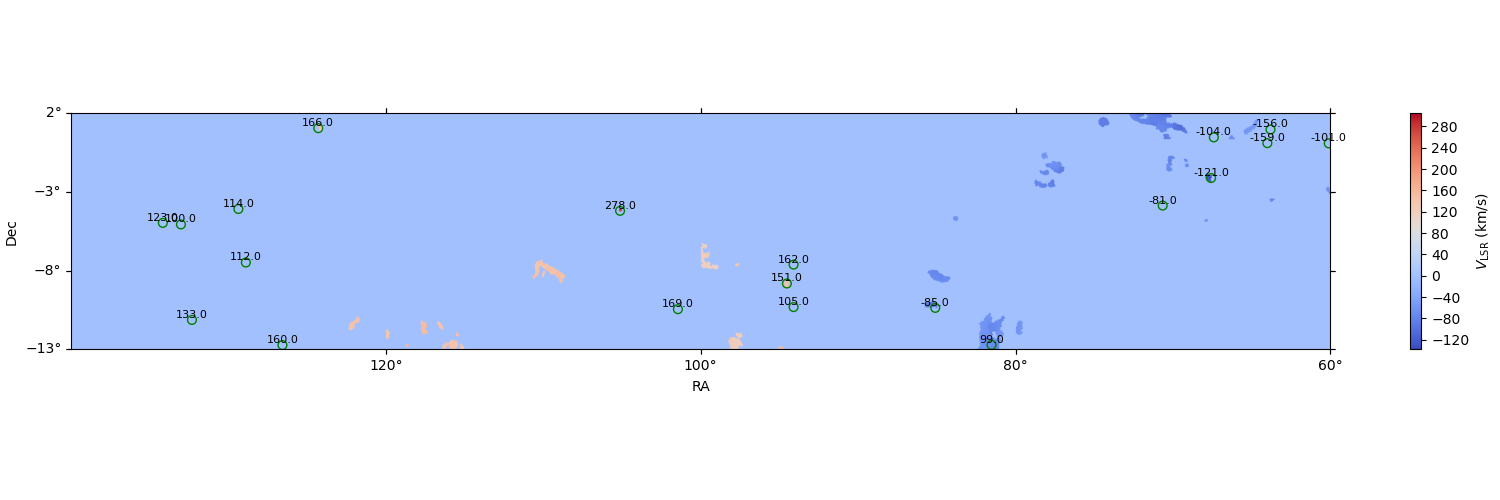

In [9]:
fig, ax = plt.subplots(
    figsize=(15, 5), layout="compressed", subplot_kw={"projection": wcs}
)
norm = simple_norm(np.array(data), stretch="linear")
im = ax.imshow(data, norm=norm, cmap='coolwarm', origin="lower")
sc = plt.scatter(
    df2_x, df2_y,
    s=40,                     # 点大小
    edgecolors='g',           # 黑色边框
    facecolors='none'         # 空心
)
# 在每个点上方标注VLSR
for xi, yi, vi in zip(df2_x, df2_y, df2_VLSR):
    plt.text(xi, yi, f'{vi:.1f}', fontsize=8, ha='center', va='bottom')
lon = ax.coords[0]
lat = ax.coords[1]
lon.set_ticks(np.arange(60, 140, 20)*u.deg)
lat.set_ticks(np.arange(-13, 7, 5)*u.deg)
lon.set_major_formatter("dd")
lat.set_major_formatter("dd")
lon.set_axislabel("RA")
lat.set_axislabel("Dec")
plt.colorbar(im, ticks=np.arange(-160,300,40), label=r'$V_{\mathrm{LSR}}\ \mathrm{(km/s)}$')
plt.show()

In [10]:
xmatch_df_top = xmatch_df.nsmallest(10, 'dist_celestial')
xmatch_df_top

,df1_ID,df1_RA,df1_Dec,df1_VLSR,df2_ID,df2_RA,df2_Dec,df2_VLSR,df1_Tpeak,df1_NHI,df2_Tpeak,df2_NHI,dist_celestial,dist_velocity,distance
30,1357,105.11,-4.21,270.05,602,105.125,-4.200,278,2.80,0.0,0.31,0.38,0.018,7.95,7.968
25,17256,94.54,-9.01,143.04,600,94.525,-8.817,151,1.06,0.0,0.17,0.10,0.194,7.96,8.154
19,7230,67.84,-2.11,-128.09,587,67.575,-2.117,-121,1.07,0.0,0.26,0.19,0.265,7.09,7.355
23,1172,85.29,-10.14,-89.44,595,85.100,-10.367,-85,1.23,0.0,0.32,0.21,0.294,4.44,4.734
21,14,85.14,-8.46,-70.52,595,85.100,-10.367,-85,2.13,0.0,0.32,0.21,1.907,14.48,16.387
10,515,70.26,-1.06,-83.81,590,70.650,-3.867,-81,0.81,0.0,0.11,0.07,2.834,2.81,5.644
7,291,67.96,-4.89,-62.47,590,70.650,-3.867,-81,0.61,0.0,0.11,0.07,2.871,18.53,21.401
8,404,69.16,-1.36,-69.11,590,70.650,-3.867,-81,0.74,0.0,0.11,0.07,2.915,11.89,14.805
13,639,69.21,-1.06,-69.92,590,70.650,-3.867,-81,0.65,0.0,0.11,0.07,3.154,11.08,14.234
27,19244,97.71,-7.69,130.56,600,94.525,-8.817,151,0.67,0.0,0.17,0.10,3.347,20.44,23.787
